## Theoretical pacing functions

In [13]:
from matplotlib import pyplot as plt
import numpy as np

MSS = 1500 
PACING_RATE = 200
RTT_US = 50_000

def linux_pacing_function(mss, pacing_rate, cwnd, rtt):
    return ((mss * 80000 * pacing_rate * cwnd) / (rtt * 8)) / 1000  

def custom_pacing_function(mss, packet_number, rtt):
    return ((mss * 1000000 * 8) / ((np.log2(packet_number + 1) - np.log2(packet_number)) * rtt * 8)) / 1000



Custom 15: 322.20160998844


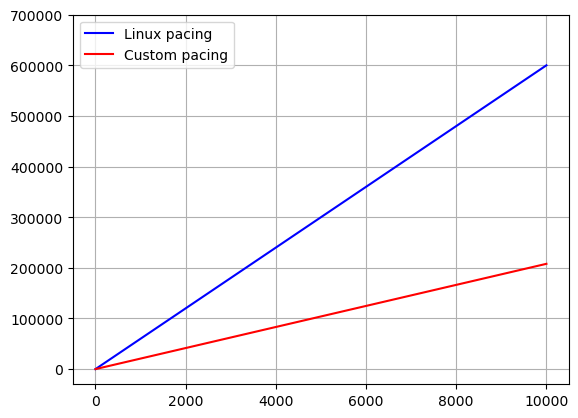

In [14]:
x = np.linspace(1, 10000, 200)
y = linux_pacing_function(MSS, PACING_RATE, x, RTT_US)

print(f"Custom 15: {custom_pacing_function(MSS, 15, RTT_US)}")

y2 = custom_pacing_function(MSS, x, RTT_US)

plt.plot(x, y, color='blue', label='Linux pacing')
plt.plot(x, y2, color='red', label='Custom pacing')
plt.grid()
plt.legend()

plt.yticks(np.arange(0, 750000, 100000))
plt.show()

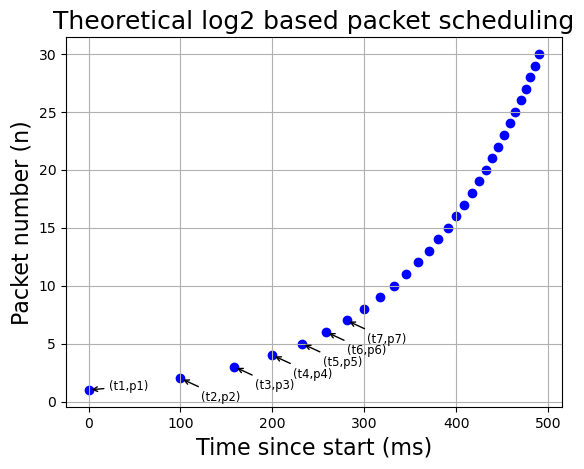

In [39]:
from matplotlib import pyplot as plt
import numpy as np

def packet_scheduling(rtt):
    y = [x for x in range(1, 31)]
    x = [ rtt * np.log2(y) for y in y ]
    x = [ms * 1000 for ms in x]
    
    labels = ["(t1,p1)", "(t2,p2)", "(t3,p3)", "(t4,p4)", "(t5,p5)", "(t6,p6)", "(t7,p7)"]
    indicies = [1, 2, 3 ,4, 5, 6]
    
    plt.annotate(
        labels[0],
        (x[0], y[0]),
        xytext=(15, 0),
        textcoords="offset points",
        arrowprops=dict(arrowstyle="->"),
        fontsize="small"
    )
    
    for i in indicies:
        plt.annotate(
            labels[i],
            (x[i], y[i]),
            xytext=(15, -16),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->"),
            fontsize="small"
        )
    
    #for xi, yi, label in zip(x, y, labels):
    #    plt.text(xi, yi, label)
        
    plt.title("Theoretical log2 based packet scheduling", fontsize=18)
    plt.xlabel("Time since start (ms)", fontsize=16)
    plt.ylabel("Packet number (n)", fontsize=16)
    
    plt.scatter(x, y, color='blue', label='Individual packet scheduling')
    
    plt.grid()
    plt.show()
    
packet_scheduling(0.1)
    